/home/romuald/PGM/pyNanoMatBuilder



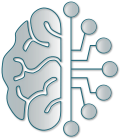

**Start at:** Wednesday 08 May 2024, 23:38:30  
**Hostname:** localhost.localdomain (Linux)

<p style="text-align: center"><img width="800px" src="./styles/svg/pyNanoMatBuilder_banner.svg" style="margin-left:auto; margin-right:auto"/></p>

In [1]:
##################
# Initialization #
##################

import os
import sys

print(os.getcwd())
cwd0 = './styles/'
sys.path.append(cwd0)

import visualID as vID
from visualID import  fg, hl, bg
vID.init(cwd0)

import numpy as np
import ase
from ase.io import write
from ase.visualize import view

import pyNanoMatBuilder.utils as pNMBu

# Bac à sable

## Interplanar spacing

In [2]:
plane = np.array([1, 3, 7])
print("CUB. expected value for [1, 3, 7] = & a=b=c=2.71: 0.3528119487580327")
unitcell = np.array([2.71, 2.71, 2.71, 90, 90, 90])
print('CUB',pNMBu.interPlanarSpacing(plane, unitcell,'CUB'))
print('TRI',pNMBu.interPlanarSpacing(plane, unitcell,'TRI'))

print()
print("HEX. expected value for [1, 3, 7] = & a=b=c=2.71, gamma=120: 0.455")
unitcell = np.array([2.71, 2.71, 2.71*1.64, 90, 90, 120])
print('HEX',pNMBu.interPlanarSpacing(plane, unitcell,'HEX'))
print('TRI',pNMBu.interPlanarSpacing(plane, unitcell,'TRI'))

print()
print("TRH. expected value for [1, 3, 7] = & a=b=c=2.71 & alpha=60: 0.357")
unitcell = np.array([2.71, 2.71, 2.71, 60, 60, 60])
print('TRH',pNMBu.interPlanarSpacing(plane, unitcell,'TRH'))
print('TRI',pNMBu.interPlanarSpacing(plane, unitcell,'TRI'))

print()
print("TET. expected value for [1, 3, 7] = & a=b=2.71 & c=2.87: 0.370")
unitcell = np.array([2.71, 2.71, 2.87, 90, 90, 90])
print('TET',pNMBu.interPlanarSpacing(plane, unitcell,'TET'))
print('TRI',pNMBu.interPlanarSpacing(plane, unitcell,'TRI'))

print()
print("ORC. expected value for [1, 3, 7] = &  a=2.71, b=2.87, c=3.12 : 0.400")
unitcell = np.array([2.71, 2.87, 3.12, 90, 90, 90])
print('ORC',pNMBu.interPlanarSpacing(plane, unitcell,'ORC'))
print('TRI',pNMBu.interPlanarSpacing(plane, unitcell,'TRI'))

print()
print("MCL. expected value for [1, 3, 7] = & a=2.71, b=2.87, c=3.12 & alpha=90, beta=120, gamma=90: 0.332")
unitcell = np.array([2.71, 2.87, 3.12, 90, 120, 90])
print('MCL',pNMBu.interPlanarSpacing(plane, unitcell,'MCL'))
print('TRI',pNMBu.interPlanarSpacing(plane, unitcell,'TRI'))

print()
print("TRI. expected value for [1, 3, 7] = & a=2.71, b=2.87, c=3.12 & alpha=33, beta=54, gamma=22: 0.296")
unitcell = np.array([2.71, 2.87, 3.12, 33, 54, 22])
print('TRI',pNMBu.interPlanarSpacing(plane, unitcell,'TRI'))

CUB. expected value for [1, 3, 7] = & a=b=c=2.71: 0.3528119487580327
CUB 0.3528119487580327
TRI 0.3528119487580327

HEX. expected value for [1, 3, 7] = & a=b=c=2.71, gamma=120: 0.455
HEX 0.4545057426000138
TRI 0.4545057426000138

TRH. expected value for [1, 3, 7] = & a=b=c=2.71 & alpha=60: 0.357
TRH 0.35738421658051656
TRI 0.35738421658051656

TET. expected value for [1, 3, 7] = & a=b=2.71 & c=2.87: 0.370
TET 0.36985128867470624
TRI 0.36985128867470624

ORC. expected value for [1, 3, 7] = &  a=2.71, b=2.87, c=3.12 : 0.400
ORC 0.3996005116459255
TRI 0.3996005116459255

MCL. expected value for [1, 3, 7] = & a=2.71, b=2.87, c=3.12 & alpha=90, beta=120, gamma=90: 0.332
MCL 0.3316855192787227
TRI 0.3316855192787227

TRI. expected value for [1, 3, 7] = & a=2.71, b=2.87, c=3.12 & alpha=33, beta=54, gamma=22: 0.296
TRI 0.2963473702102916


## Plane fitting to N atoms positions

### A word about planes

<div class="intro">

The plane through $P_0(x_0,y_0,z_0)$ with normal ....

$$a(x-x_0)+b(y-y_0)+c(z-z_0)=0$$

$$ax+by+cz=(ax_0+by_0+cz_0)$$
</div>

### Code

In [3]:
from pyNanoMatBuilder import utils as pNMBu
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def planeFitting(coords: np.float64):
    import numpy as np
    xs = coords[:,0]
    ys = coords[:,1]
    zs = coords[:,2]
    tmp_A = []
    tmp_b = []
    for i in range(len(xs)):
        tmp_A.append([xs[i], ys[i], 1])
        tmp_b.append(zs[i])
    b = np.matrix(tmp_b).T
    A = np.matrix(tmp_A)
    fit = (A.T * A).I * A.T * b
    errors = b - A * fit
    residual = np.linalg.norm(errors)
    
    print(f"solution: {fit[0].item()} x + {fit[1].item()} y + {fit[2].item()} = z")
    print(f"errors:")
    print(errors)
    print(f"residual: {residual}")
    return fit[0].item(), fit[1].item(), fit[2].item()





### Examples

solution: 2.6513328205860196 x + 3.6830570932387436 y + 3.5405736157262258 = z
errors:
[[ -0.25669974]
 [  1.98644487]
 [  1.83355175]
 [-11.9531497 ]
 [ -2.48868772]
 [  1.67613835]
 [ -0.91629161]
 [ -4.04546793]
 [ 10.4178058 ]
 [  3.74635593]]
residual: 17.2923632178434
bare solution: 0.66174 x + 0.73025 y + -0.16979 z + 0.41160 = 0
     or
bare solution: 3.89745 x + 4.30095 y + 2.42421 = z
errors:
[[ 0.59939178]
 [ 0.24468539]
 [-0.40183913]
 [ 2.1089222 ]
 [-0.2290895 ]
 [-1.00512265]
 [ 0.12656679]
 [ 1.19081567]
 [-1.3851909 ]
 [-1.24913966]]
residual: 3.31724092057971
hkl solution: 3.89745 x + 4.30095 y + -1.00000 z + 2.42421 = 0
     or
hkl solution: 3.89745 x + 4.30095 y + 2.42421 = z


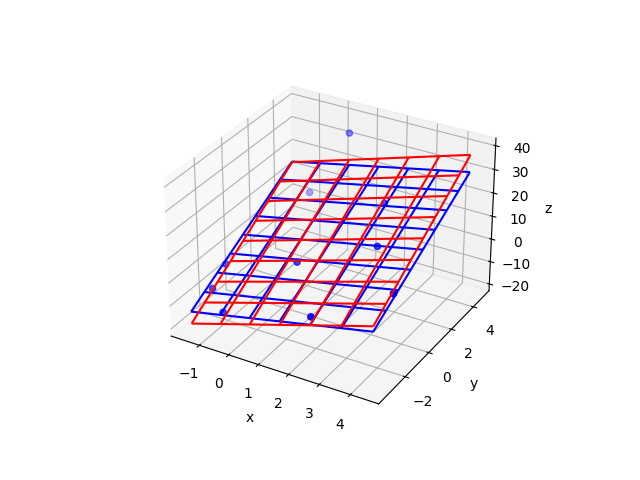

Distance between the [0 0 0] point and the (4 4 -1) plane = 0.412


In [5]:
%matplotlib widget 

N_POINTS = 10
TARGET_X_SLOPE = 2
TARGET_y_SLOPE = 3
TARGET_OFFSET  = 5
EXTENTS = 5
NOISE = 5

# create random data
xs = [np.random.uniform(2*EXTENTS)-EXTENTS for i in range(N_POINTS)]
ys = [np.random.uniform(2*EXTENTS)-EXTENTS for i in range(N_POINTS)]
zs = []
for i in range(N_POINTS):
    zs.append(xs[i]*TARGET_X_SLOPE + \
              ys[i]*TARGET_y_SLOPE + \
              TARGET_OFFSET + np.random.normal(scale=NOISE))

coords = np.column_stack((xs,ys,zs))

# do fit

u,v,w = planeFitting(coords)
plane = pNMBu.hklPlaneFitting(coords,True)
    
# plot raw data
plt.figure()
ax = plt.subplot(111, projection='3d')
ax.scatter(xs, ys, zs, color='b')
# plot plane
xlim = ax.get_xlim()
ylim = ax.get_ylim()
X,Y = np.meshgrid(np.arange(xlim[0], xlim[1]),
                  np.arange(ylim[0], ylim[1]))
Z = np.zeros(X.shape)
ZLSF = np.zeros(X.shape)
for row in range(X.shape[0]):
    for col in range(X.shape[1]):
        Z[row,col] = u * X[row,col] + v * Y[row,col] + w
        ZLSF[row,col] = (-plane[0]/plane[2]) * X[row,col] - (plane[1]/plane[2]) * Y[row,col] - plane[3]/plane[2]
ax.plot_wireframe(X,Y,Z, color='b')
ax.plot_wireframe(X,Y,ZLSF, color='r')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

point = np.array([0,0,0])
d = pNMBu.point2PlaneDistance(point,plane)
print(f"Distance between the {point} point and the ({plane[0]:.0f} {plane[1]:.0f} {plane[2]:.0f}) plane = {d:.3f}")

solution: 0.0 x + 6.938893903907228e-17 y + 1.0 = z
errors:
[[-2.22044605e-16]
 [ 0.00000000e+00]
 [ 1.11022302e-16]
 [-2.22044605e-16]
 [-2.22044605e-16]
 [-2.22044605e-16]
 [-2.22044605e-16]
 [ 0.00000000e+00]
 [ 1.11022302e-16]
 [ 1.11022302e-16]]
residual: 5.324442579404919e-16
bare solution: 0.00000 x + 0.00000 y + 1.00000 z + -1.00000 = 0
     or
bare solution: -0.00000 x + -0.00000 y + 1.00000 = z
errors:
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
residual: 0.0
hkl solution: 0.00000 x + 0.00000 y + 1.00000 z + -1.00000 = 0
     or
hkl solution: -0.00000 x + -0.00000 y + 1.00000 = z


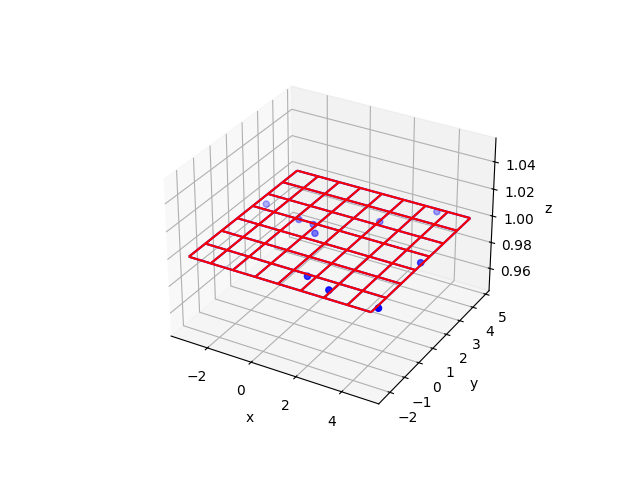

Distance between the [0 0 0] point and the (0 0 1) plane = 1.000


In [7]:
from pyNanoMatBuilder import utils as pNMBu
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

N_POINTS = 10
TARGET_X_SLOPE = 2
TARGET_y_SLOPE = 3
TARGET_OFFSET  = 5
EXTENTS = 5
NOISE = 5

# create random data
xs = [np.random.uniform(2*EXTENTS)-EXTENTS for i in range(N_POINTS)]
ys = [np.random.uniform(2*EXTENTS)-EXTENTS for i in range(N_POINTS)]
zs = [1 for  i in range(N_POINTS)]

coords = np.column_stack((xs,ys,zs))
# do fit

u,v,w = planeFitting(coords)
plane = pNMBu.hklPlaneFitting(coords)
    
# plot raw data
plt.figure()
ax = plt.subplot(111, projection='3d')
ax.scatter(xs, ys, zs, color='b')
# plot plane
xlim = ax.get_xlim()
ylim = ax.get_ylim()
X,Y = np.meshgrid(np.arange(xlim[0], xlim[1]),
                  np.arange(ylim[0], ylim[1]))
Z = np.zeros(X.shape)
ZLSF = np.zeros(X.shape)
for row in range(X.shape[0]):
    for col in range(X.shape[1]):
        Z[row,col] = u * X[row,col] + v * Y[row,col] + w
        ZLSF[row,col] = (-plane[0]/plane[2]) * X[row,col] - (plane[1]/plane[2]) * Y[row,col] - plane[3]/plane[2]
ax.plot_wireframe(X,Y,Z, color='b')
ax.plot_wireframe(X,Y,ZLSF, color='r')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

point = np.array([0,0,0])
d = pNMBu.point2PlaneDistance(point,plane)
print(f"Distance between the {point} point and the ({plane[0]:.0f} {plane[1]:.0f} {plane[2]:.0f}) plane = {d:.3f}")

solution: -0.9999999999977818 x + -0.9999999999977816 y + 12.234743684192429 = z
errors:
[[-3.68420148e-06]
 [-3.68420600e-06]
 [-3.68420600e-06]
 [-3.68421052e-06]
 [ 6.31579852e-06]
 [-3.68421505e-06]
 [ 6.31578948e-06]
 [-3.68420600e-06]
 [-3.68420600e-06]
 [-3.68421052e-06]
 [ 6.31579852e-06]
 [-3.68421505e-06]
 [-3.68421505e-06]
 [-3.68421957e-06]
 [ 6.31578948e-06]
 [ 6.31578043e-06]
 [-3.68421505e-06]
 [ 6.31578948e-06]
 [ 6.31578043e-06]]
residual: 2.10262993207779e-05
bare solution: -0.57735 x + -0.57735 y + -0.57735 z + 7.06373 = 0
     or
bare solution: -1.00000 x + -1.00000 y + 12.23474 = z
hkl solution: -1.00000 x + -1.00000 y + -1.00000 z + 12.23474 = 0
     or
hkl solution: -1.00000 x + -1.00000 y + 12.23474 = z


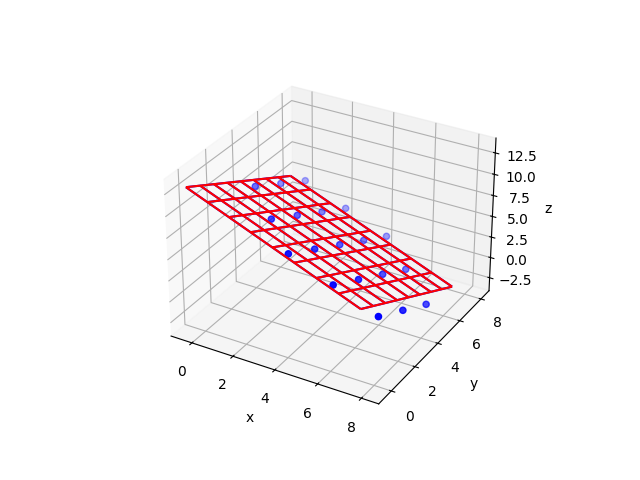

Distance between the [0 0 0] point and the (-1 -1 -1) plane = 7.064


In [7]:
coords = np.array([[     2.03912   ,   2.03912  ,    8.15650],
[     0.00000    ,  6.11737   ,   6.11737],
[     2.03912    ,  4.07825   ,   6.11737],
[     2.03912    ,  6.11737   ,   4.07825],
[     0.00000    ,  4.07825   ,   8.15650],
[     2.03912    ,  8.15650   ,   2.03912],
[     0.00000    ,  8.15650   ,   4.07825],
[     4.07825    ,  2.03912   ,   6.11737],
[     6.11737    ,  0.00000   ,   6.11737],
[     6.11737    ,  2.03912   ,   4.07825],
[     4.07825    ,  0.00000   ,   8.15650],
[     4.07825    ,  6.11737   ,   2.03912],
[     6.11737    ,  4.07825   ,   2.03912],
[     6.11737    ,  6.11737   ,   0.00000],
[     4.07825    ,  4.07825   ,   4.07825],
[     4.07825    ,  8.15650   ,   0.00000],
[     8.15650    ,  2.03912   ,   2.03912],
[     8.15650    ,  0.00000   ,   4.07825],
[     8.15650    ,  4.07825   ,   0.00000]])

xs = coords[:,0]
ys = coords[:,1]
zs = coords[:,2]

# do fit

u,v,w = planeFitting(coords)
plane = pNMBu.hklPlaneFitting(coords)
    
# plot raw data
plt.figure()
ax = plt.subplot(111, projection='3d')
ax.scatter(xs, ys, zs, color='b')
# plot plane
xlim = ax.get_xlim()
ylim = ax.get_ylim()
X,Y = np.meshgrid(np.arange(xlim[0], xlim[1]),
                  np.arange(ylim[0], ylim[1]))
Z = np.zeros(X.shape)
ZLSF = np.zeros(X.shape)
for row in range(X.shape[0]):
    for col in range(X.shape[1]):
        Z[row,col] = u * X[row,col] + v * Y[row,col] + w
        ZLSF[row,col] = (-plane[0]/plane[2]) * X[row,col] - (plane[1]/plane[2]) * Y[row,col] - plane[3]/plane[2]
ax.plot_wireframe(X,Y,Z, color='b')
ax.plot_wireframe(X,Y,ZLSF, color='r')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

point = np.array([0,0,0])
d = pNMBu.point2PlaneDistance(point,plane)
print(f"Distance between the {point} point and the ({plane[0]:.0f} {plane[1]:.0f} {plane[2]:.0f}) plane = {d:.3f}")

solution: 0.999999999997152 x + -0.9999999999971516 y + 4.078247499998064 = z
errors:
[[-7.50000387e-06]
 [ 2.50000194e-06]
 [ 2.50000774e-06]
 [ 2.50000194e-06]
 [ 2.49999032e-06]
 [ 2.49999613e-06]
 [ 2.49999032e-06]
 [-7.49999226e-06]
 [-7.50000387e-06]
 [ 2.50000193e-06]
 [ 2.50000774e-06]
 [ 2.50000193e-06]]
residual: 1.4999999999002289e-05
bare solution: 0.57735 x + -0.57735 y + -0.57735 z + 2.35458 = 0
     or
bare solution: 1.00000 x + -1.00000 y + 4.07825 = z
hkl solution: 1.00000 x + -1.00000 y + -1.00000 z + 4.07825 = 0
     or
hkl solution: 1.00000 x + -1.00000 y + 4.07825 = z


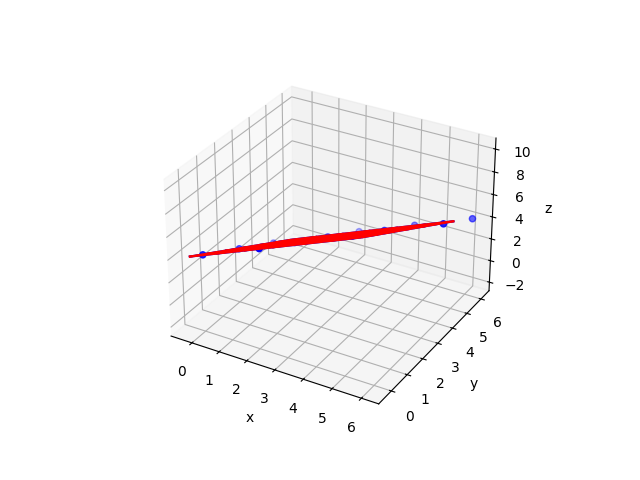

Distance between the [0 0 0] point and the (1 -1 -1) plane = 2.355


In [8]:
coords = np.array([[0.00000    ,  2.03912  ,    2.03912],
 [0.00000    ,  0.00000  ,    4.07825],
 [2.03912    ,  0.00000  ,    6.11737],
 [2.03912    ,  2.03912  ,    4.07825],
 [0.00000    ,  4.07825  ,    0.00000],
 [2.03912    ,  4.07825  ,    2.03912],
 [2.03912    ,  6.11737  ,    0.00000],
 [4.07825    ,  2.03912  ,    6.11737],
 [4.07825    ,  6.11737  ,    2.03912],
 [4.07825    ,  4.07825  ,    4.07825],
 [6.11737    ,  4.07825  ,    6.11737],
 [6.11737    ,  6.11737  ,    4.07825]])

xs = coords[:,0]
ys = coords[:,1]
zs = coords[:,2]

# do fit

u,v,w = planeFitting(coords)
plane = pNMBu.hklPlaneFitting(coords)
    
# plot raw data
plt.figure()
ax = plt.subplot(111, projection='3d')
ax.scatter(xs, ys, zs, color='b')
# plot plane
xlim = ax.get_xlim()
ylim = ax.get_ylim()
X,Y = np.meshgrid(np.arange(xlim[0], xlim[1]),
                  np.arange(ylim[0], ylim[1]))
Z = np.zeros(X.shape)
ZLSF = np.zeros(X.shape)
for row in range(X.shape[0]):
    for col in range(X.shape[1]):
        Z[row,col] = u * X[row,col] + v * Y[row,col] + w
        ZLSF[row,col] = (-plane[0]/plane[2]) * X[row,col] - (plane[1]/plane[2]) * Y[row,col] - plane[3]/plane[2]
ax.plot_wireframe(X,Y,Z, color='b')
ax.plot_wireframe(X,Y,ZLSF, color='r')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

point = np.array([0,0,0])
d = pNMBu.point2PlaneDistance(point,plane)
print(f"Distance between the {point} point and the ({plane[0]:.0f} {plane[1]:.0f} {plane[2]:.0f}) plane = {d:.3f}")

solution: -0.9999999999999998 x + -1.0 y + 1.9999999999999996 = z
errors:
[[4.44089210e-16]
 [2.22044605e-16]
 [2.22044605e-16]
 [4.44089210e-16]
 [4.44089210e-16]
 [0.00000000e+00]]
residual: 8.308148362110449e-16
bare solution: -0.57735 x + -0.57735 y + -0.57735 z + 1.15470 = 0
     or
bare solution: -1.00000 x + -1.00000 y + 2.00000 = z
hkl solution: -1.00000 x + -1.00000 y + -1.00000 z + 2.00000 = 0
     or
hkl solution: -1.00000 x + -1.00000 y + 2.00000 = z


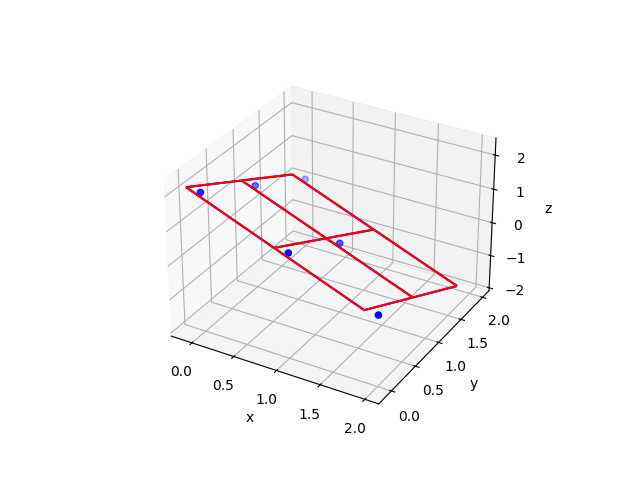

Distance between the [0 0 0] point and the (-1 -1 -1) plane = 1.155


In [3]:
%matplotlib widget 
coords=np.array([[ 0.00000   ,   1  ,    1],
                 [ 1   ,   0.00000  ,    1],
                 [ 1   ,   1  ,    0.00000],
                 [ 0.00000   ,   0.00000  ,    2],
                 [ 0.00000   ,   2  ,    0.00000],
                 [ 2   ,   0.00000  ,    0.00000]])

xs = coords[:,0]
ys = coords[:,1]
zs = coords[:,2]

# do fit

u,v,w = planeFitting(coords)
plane = pNMBu.hklPlaneFitting(coords)
    
# plot raw data
plt.figure()
ax = plt.subplot(111, projection='3d')
ax.scatter(xs, ys, zs, color='b')
# plot plane
xlim = ax.get_xlim()
ylim = ax.get_ylim()
X,Y = np.meshgrid(np.arange(xlim[0], xlim[1]),
                  np.arange(ylim[0], ylim[1]))
Z = np.zeros(X.shape)
ZLSF = np.zeros(X.shape)
for row in range(X.shape[0]):
    for col in range(X.shape[1]):
        Z[row,col] = u * X[row,col] + v * Y[row,col] + w
        ZLSF[row,col] = (-plane[0]/plane[2]) * X[row,col] - (plane[1]/plane[2]) * Y[row,col] - plane[3]/plane[2]
ax.plot_wireframe(X,Y,Z, color='b')
ax.plot_wireframe(X,Y,ZLSF, color='r')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

point = np.array([0,0,0])
d = pNMBu.point2PlaneDistance(point,plane)
print(f"Distance between the {point} point and the ({plane[0]:.0f} {plane[1]:.0f} {plane[2]:.0f}) plane = {d:.3f}")

In [12]:
print(1.1547005383792515/2)
print(np.sqrt(3)/3)

0.5773502691896257
0.5773502691896257


### Parallel planes & above/below routines

<div class="intro">

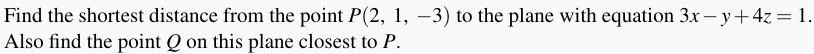

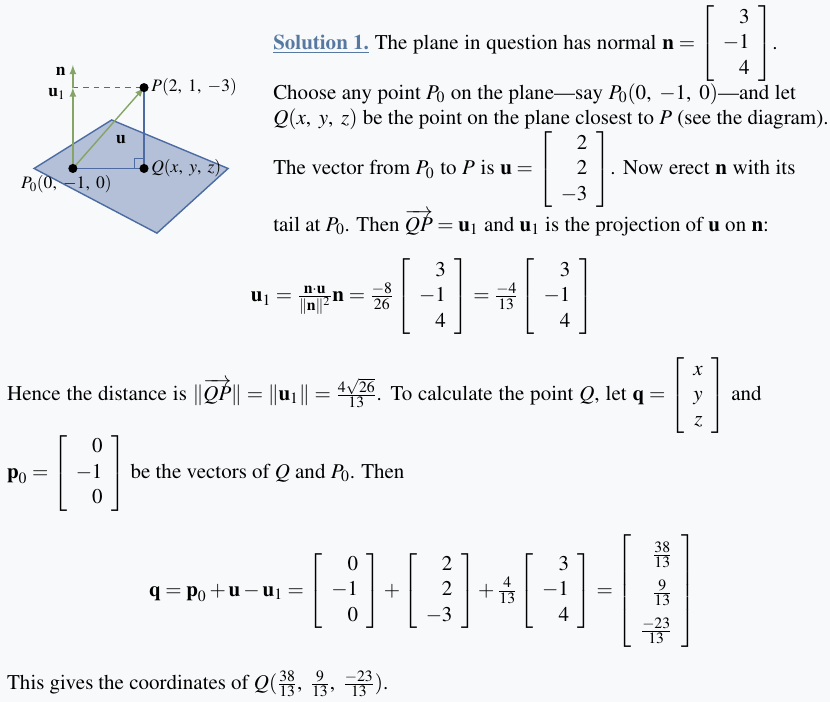
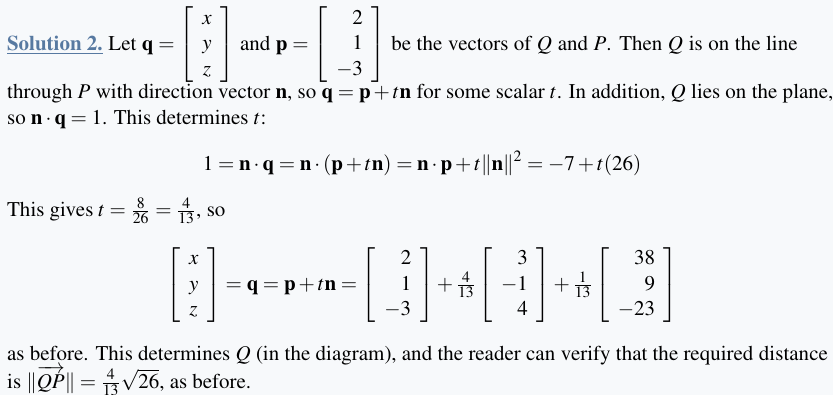
</div>

#### 1st example

bare solution: 0.00000 x + 0.00000 y + 1.00000 z + -2.03912 = 0
     or
bare solution: -0.00000 x + -0.00000 y + 2.03912 = z
hkl solution: 0.00000 x + 0.00000 y + 1.00000 z + -2.03912 = 0
     or
hkl solution: -0.00000 x + -0.00000 y + 2.03912 = z


bare solution: 0.00000 x + 0.00000 y + 1.00000 z + -3.05868 = 0
     or
bare solution: -0.00000 x + -0.00000 y + 3.05868 = z
hkl solution: 0.00000 x + 0.00000 y + 1.00000 z + -3.05868 = 0
     or
hkl solution: -0.00000 x + -0.00000 y + 3.05868 = z


bare solution: 0.00000 x + 0.00000 y + 1.00000 z + 1.00000 = 0
     or
bare solution: -0.00000 x + -0.00000 y + -1.00000 = z
hkl solution: 0.00000 x + 0.00000 y + 1.00000 z + 1.00000 = 0
     or
hkl solution: -0.00000 x + -0.00000 y + -1.00000 = z


hkl solution: 0.00000 x + 0.00000 y + 1.00000 z + -2.50000 = 0
     or
hkl solution: -0.00000 x + -0.00000 y + 2.50000 = z


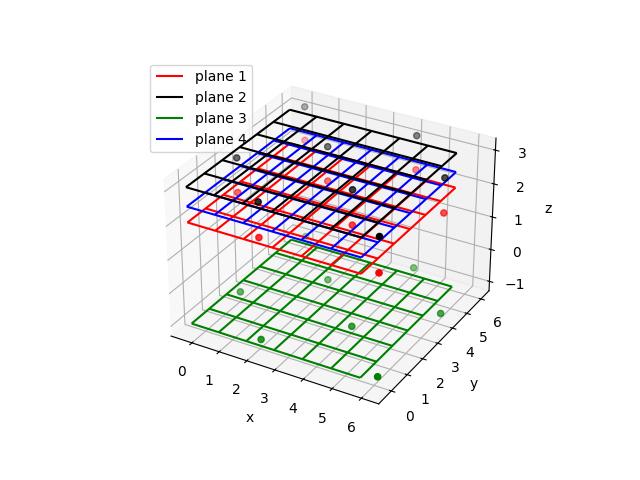

Distance between the [0 0 0] point and the (0 0 1: -2.039) plane1 = 2.039
Distance between the [0 0 0] point and the (0 0 1: -3.059) plane2 = 3.059
Distance between the [0 0 0] point and the (0 0 1: 1.000) plane3 = 1.000

Distance between the [ 0.   0.  -2.5] point and the (0 0 1: -2.039) plane1 = 4.539
Distance between the [ 0.   0.  -2.5] point and the (0 0 1: -3.059) plane2 = 5.559
Distance between the [ 0.   0.  -2.5] point and the (0 0 1: 1.000) plane3 = 1.500

Vector between the [1.  2.  2.5] point and the (0 0 1: -2.039) plane1 = [-0.0 -0.0 -0.46087999999999996] (distance = 0.461). t = 0.461
Vector between the [1.  2.  2.5] point and the (0 0 1: -3.059) plane2 = [6.624542291936196e-33 6.62454229193619e-33 0.5586799999999994] (distance = 0.559). t = -0.559
Vector between the [1.  2.  2.5] point and the (0 0 1: 1.000) plane3 = [-0.0 -0.0 -3.5] (distance = 3.500). t = 3.500

Vector between the [ 1.    2.   -0.25] point and the (0 0 1: -2.039) plane1 = [0.0 0.0 2.28912] (distance = 

In [6]:
import importlib
importlib.reload(pNMBu)
from matplotlib import pyplot as plt


%matplotlib widget 
coords1=np.array([[0.00000 ,     2.03912,      2.03912],
 [2.03912 ,     0.00000,      2.03912],
 [0.00000 ,     6.11737,      2.03912],
 [2.03912 ,     4.07825,      2.03912],
 [4.07825 ,     2.03912,      2.03912],
 [6.11737 ,     0.00000,      2.03912],
 [4.07825 ,     6.11737,      2.03912],
 [6.11737 ,     4.07825,      2.03912]])
xs1 = coords1[:,0]
ys1 = coords1[:,1]
zs1 = coords1[:,2]

coords2=np.array([[0.00000 ,     2.03912,      3.05868],
 [2.03912 ,     0.00000,      3.05868],
 [0.00000 ,     6.11737,      3.05868],
 [2.03912 ,     4.07825,      3.05868],
 [4.07825 ,     2.03912,      3.05868],
 [6.11737 ,     0.00000,      3.05868],
 [4.07825 ,     6.11737,      3.05868],
 [6.11737 ,     4.07825,      3.05868]])
xs2 = coords2[:,0]
ys2 = coords2[:,1]
zs2 = coords2[:,2]

coords3=np.array([[0.00000 ,     2.03912,      -1],
                 [2.03912 ,     0.00000,      -1],
                 [0.00000 ,     6.11737,      -1],
                 [2.03912 ,     4.07825,      -1],
                 [4.07825 ,     2.03912,      -1],
                 [6.11737 ,     0.00000,      -1],
                 [4.07825 ,     6.11737,      -1],
                 [6.11737 ,     4.07825,      -1]])
xs3 = coords3[:,0]
ys3 = coords3[:,1]
zs3 = coords3[:,2]

# do fit

vID.centerTitle("Plane 1")
plane1 = pNMBu.hklPlaneFitting(coords1)
vID.centerTitle("Plane 2")
plane2 = pNMBu.hklPlaneFitting(coords2)
vID.centerTitle("Plane 3")
plane3 = pNMBu.hklPlaneFitting(coords3)

vID.centerTitle("Plane 4, parallel to planes 1 & 2, and passing through [1,2,2.5]")
plane4=plane2.copy()
P0 = np.array([1,2,2.5])
plane4[3]=-np.dot(plane4[0:3],P0)
print(f"hkl solution: {plane4[0]:.5f} x + {plane4[1]:.5f} y + {plane4[2]:.5f} z + {plane4[3]:.5f} = 0")
print("     or")
print(f"hkl solution: {-plane4[0]/plane4[2]:.5f} x + {-plane4[1]/plane4[2]:.5f} y + {-plane4[3]/plane4[2]:.5f} = z")

vID.centerTitle("Plot")
# plot raw data
plt.figure()
ax = plt.subplot(111, projection='3d')
ax.scatter(xs1, ys1, zs1, color='r')
ax.scatter(xs2, ys2, zs2, color='black')
ax.scatter(xs3, ys3, zs3, color='green')
# plot plane
xlim = ax.get_xlim()
ylim = ax.get_ylim()
X,Y = np.meshgrid(np.arange(xlim[0], xlim[1]),
                  np.arange(ylim[0], ylim[1]))
ZLSF1 = np.zeros(X.shape)
ZLSF2 = np.zeros(X.shape)
ZLSF3 = np.zeros(X.shape)
ZLSF4 = np.zeros(X.shape)
for row in range(X.shape[0]):
    for col in range(X.shape[1]):
        ZLSF1[row,col] = (-plane1[0]/plane1[2]) * X[row,col] - (plane1[1]/plane1[2]) * Y[row,col] - plane1[3]/plane1[2]
        ZLSF2[row,col] = (-plane2[0]/plane2[2]) * X[row,col] - (plane2[1]/plane2[2]) * Y[row,col] - plane2[3]/plane2[2]
        ZLSF3[row,col] = (-plane3[0]/plane3[2]) * X[row,col] - (plane3[1]/plane3[2]) * Y[row,col] - plane3[3]/plane3[2]
        ZLSF4[row,col] = (-plane4[0]/plane4[2]) * X[row,col] - (plane4[1]/plane4[2]) * Y[row,col] - plane4[3]/plane4[2]
ax.plot_wireframe(X,Y,ZLSF1, color='r',label='plane 1')
ax.plot_wireframe(X,Y,ZLSF2, color='black',label='plane 2')
ax.plot_wireframe(X,Y,ZLSF3, color='green',label='plane 3')
ax.plot_wireframe(X,Y,ZLSF4, color='blue',label='plane 4')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()
plt.show()

vID.centerTitle("Shortest distance and vector between a point and a plane")
point1 = np.array([0,0,0])
d1 = pNMBu.point2PlaneDistance(point1,plane1)
d2 = pNMBu.point2PlaneDistance(point1,plane2)
d3 = pNMBu.point2PlaneDistance(point1,plane3)
print(f"Distance between the {point1} point and the ({plane1[0]:.0f} {plane1[1]:.0f} {plane1[2]:.0f}: {plane1[3]:.3f}) plane1 = {d1:.3f}")
print(f"Distance between the {point1} point and the ({plane2[0]:.0f} {plane2[1]:.0f} {plane2[2]:.0f}: {plane2[3]:.3f}) plane2 = {d2:.3f}")
print(f"Distance between the {point1} point and the ({plane3[0]:.0f} {plane3[1]:.0f} {plane3[2]:.0f}: {plane3[3]:.3f}) plane3 = {d3:.3f}")

point2 = np.array([0,0,-2.5])
d1 = pNMBu.point2PlaneDistance(point2,plane1)
d2 = pNMBu.point2PlaneDistance(point2,plane2)
d3 = pNMBu.point2PlaneDistance(point2,plane3)
print()
print(f"Distance between the {point2} point and the ({plane1[0]:.0f} {plane1[1]:.0f} {plane1[2]:.0f}: {plane1[3]:.3f}) plane1 = {d1:.3f}")
print(f"Distance between the {point2} point and the ({plane2[0]:.0f} {plane2[1]:.0f} {plane2[2]:.0f}: {plane2[3]:.3f}) plane2 = {d2:.3f}")
print(f"Distance between the {point2} point and the ({plane3[0]:.0f} {plane3[1]:.0f} {plane3[2]:.0f}: {plane3[3]:.3f}) plane3 = {d3:.3f}")

print()
v1,d1 = pNMBu.shortestPoint2PlaneVectorDistance(plane1,P0)
t1 = pNMBu.Pt2planeSignedDistance(plane1,P0)
print(f"Vector between the {P0} point and the ({plane1[0]:.0f} {plane1[1]:.0f} {plane1[2]:.0f}: {plane1[3]:.3f}) plane1 = {v1} (distance = {d1:.3f}). t = {t1:.3f}")
v2,d2 = pNMBu.shortestPoint2PlaneVectorDistance(plane2,P0)
t2 = pNMBu.Pt2planeSignedDistance(plane2,P0)
print(f"Vector between the {P0} point and the ({plane2[0]:.0f} {plane2[1]:.0f} {plane2[2]:.0f}: {plane2[3]:.3f}) plane2 = {v2} (distance = {d2:.3f}). t = {t2:.3f}")
v3,d3 = pNMBu.shortestPoint2PlaneVectorDistance(plane3,P0)
t3 = pNMBu.Pt2planeSignedDistance(plane3,P0)
print(f"Vector between the {P0} point and the ({plane3[0]:.0f} {plane3[1]:.0f} {plane3[2]:.0f}: {plane3[3]:.3f}) plane3 = {v3} (distance = {d3:.3f}). t = {t3:.3f}")
print()
P1 = np.array([1.,2.,-0.25])
v1,d1 = pNMBu.shortestPoint2PlaneVectorDistance(plane1,P1)
t1 = pNMBu.Pt2planeSignedDistance(plane1,P1)
print(f"Vector between the {P1} point and the ({plane1[0]:.0f} {plane1[1]:.0f} {plane1[2]:.0f}: {plane1[3]:.3f}) plane1 = {v1} (distance = {d1:.3f}). t = {t1:.3f}")
v2,d2 = pNMBu.shortestPoint2PlaneVectorDistance(plane2,P1)
t2 = pNMBu.Pt2planeSignedDistance(plane2,P1)
print(f"Vector between the {P1} point and the ({plane2[0]:.0f} {plane2[1]:.0f} {plane2[2]:.0f}: {plane2[3]:.3f}) plane2 = {v2} (distance = {d2:.3f}). t = {t2:.3f}")
v3,d3 = pNMBu.shortestPoint2PlaneVectorDistance(plane3,P1)
t3 = pNMBu.Pt2planeSignedDistance(plane3,P1)
print(f"Vector between the {P1} point and the ({plane3[0]:.0f} {plane3[1]:.0f} {plane3[2]:.0f}: {plane3[3]:.3f}) plane3 = {v3} (distance = {d3:.3f}). t = {t3:.3f}")

#### 2nd example

bare solution: -0.57735 x + -0.57735 y + -0.57735 z + 2.30940 = 0
     or
bare solution: -1.00000 x + -1.00000 y + 4.00000 = z
hkl solution: -1.00000 x + -1.00000 y + -1.00000 z + 4.00000 = 0
     or
hkl solution: -1.00000 x + -1.00000 y + 4.00000 = z


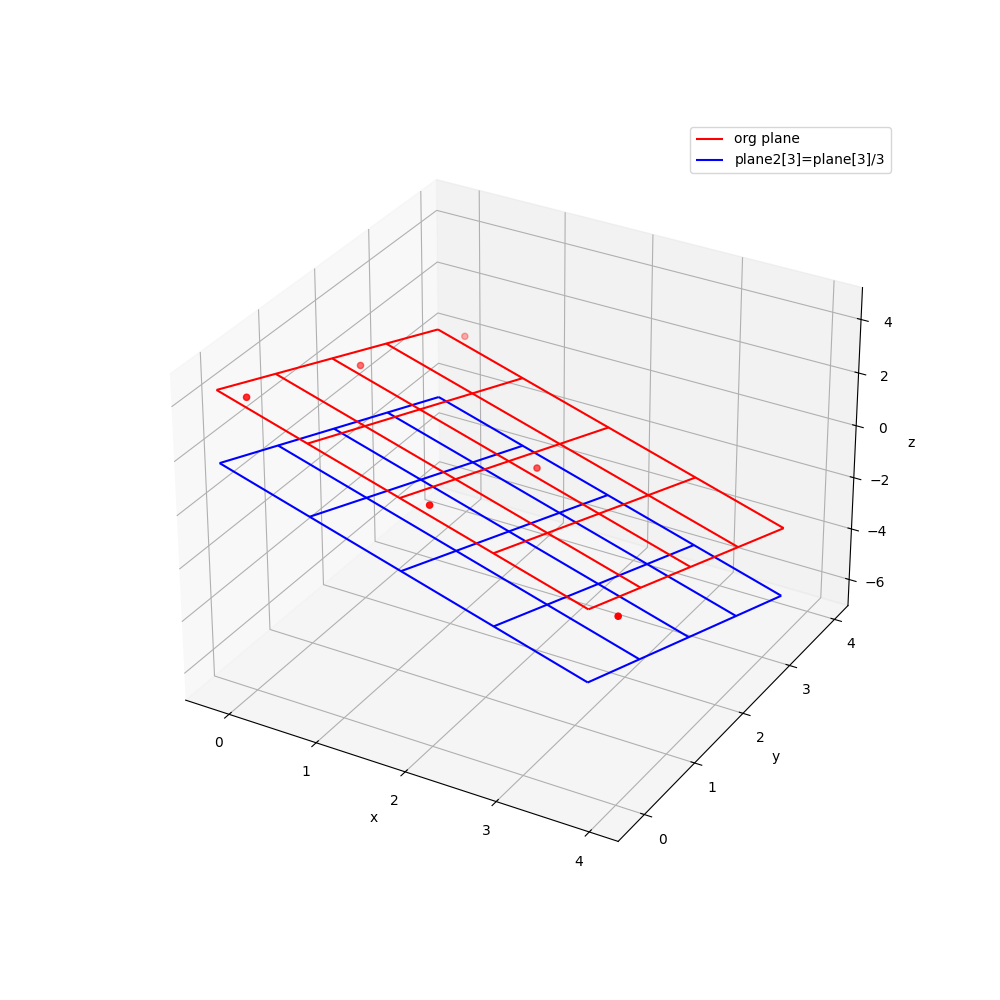

Distance between the [0 0 0] point and the (-1 -1 -1: 4.000) plane = 2.309, t = 2.309
Distance between the [0 0 0] point and the (-1 -1 -1: 1.333) plane2 = 0.770, t = 0.770


In [7]:
%matplotlib widget 

coords=np.array([[ 0.00000   ,   2  ,    2],
                 [ 2   ,   0.00000  ,    2],
                 [ 2   ,   2  ,    0.00000],
                 [ 0.00000   ,   0.00000  ,    4],
                 [ 0.00000   ,   4  ,    0.00000],
                 [ 4   ,   0.00000  ,    0.00000]])

xs = coords[:,0]
ys = coords[:,1]
zs = coords[:,2]

# do fit

# u,v,w = planeFitting(coords)
plane = pNMBu.hklPlaneFitting(coords)
plane2 = plane.copy()
plane2[3]=plane2[3]/3
    
# plot raw data
plt.figure(figsize=(10,10))
ax = plt.subplot(111, projection='3d')
ax.scatter(xs, ys, zs, color='red')
# plot plane
xlim = ax.get_xlim()
ylim = ax.get_ylim()
X,Y = np.meshgrid(np.arange(xlim[0], xlim[1]),
                  np.arange(ylim[0], ylim[1]))
# Z = np.zeros(X.shape)
ZLSF = np.zeros(X.shape)
ZLSF2 = np.zeros(X.shape)
for row in range(X.shape[0]):
    for col in range(X.shape[1]):
        # Z[row,col] = u * X[row,col] + v * Y[row,col] + w
        ZLSF[row,col] = (-plane[0]/plane[2]) * X[row,col] - (plane[1]/plane[2]) * Y[row,col] - plane[3]/plane[2]
        ZLSF2[row,col] = (-plane2[0]/plane2[2]) * X[row,col] - (plane2[1]/plane2[2]) * Y[row,col] - plane2[3]/plane2[2]
# ax.plot_wireframe(X,Y,Z, color='red')
ax.plot_wireframe(X,Y,ZLSF, color='red',label='org plane')
ax.plot_wireframe(X,Y,ZLSF2, color='blue',label='plane2[3]=plane[3]/3')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.legend()
plt.show()

point = np.array([0,0,0])
d = pNMBu.point2PlaneDistance(point,plane)
t = pNMBu.Pt2planeSignedDistance(plane,point)
print(f"Distance between the {point} point and the ({plane[0]:.0f} {plane[1]:.0f} {plane[2]:.0f}: {plane[3]:.3f}) plane = {d:.3f}, t = {t:.3f}")
d2 = pNMBu.point2PlaneDistance(point,plane2)
t2 = pNMBu.Pt2planeSignedDistance(plane2,point)
print(f"Distance between the {point} point and the ({plane2[0]:.0f} {plane2[1]:.0f} {plane2[2]:.0f}: {plane2[3]:.3f}) plane2 = {d2:.3f}, t = {t2:.3f}")

## Structures for TEM image recognition

### Tetrahedron

In [2]:
from pyNanoMatBuilder import platonicNPs as pNP
nLayers = 25
vID.centerTitle(f"fcc Td: {nLayers} atoms/edge = number of layers")
Td = pNP.regfccTd("Pt",2.7,nLayers)

vID.centertxt("Properties",bgc='#007a7a',size='14',weight='bold')
Td.prop()

vID.centertxt("Generation of coordinates",bgc='#007a7a',size='14',weight='bold')
aseTd,atTd = Td.coords()
view(aseTd)
write("coords/Td.xyz", aseTd)

pNMBu.moi(aseTd)
pNMBu.MolSym(aseTd)

aseTdOpt = pNMBu.optimizeEMT(aseTd,'./coords/Td')

pNMBu.moi(aseTdOpt)
pNMBu.MolSym(aseTdOpt)

Regular tetrahedron with 25 layer(s) and Rnn = 2.7
element =  Pt
number of vertices =  4
number of edges =  6
number of faces =  4
nearest neighbour distance = 2.70 Å
edge length = 6.48 nm
number of atoms per edge = 25
height of pyramid = 0.16 nm
radius after volume = 1.97 nm
radius of the circumscribed sphere = 7.94 nm
radius of the inscribed sphere = 2.65 nm
radius of the midsphere that is tangent to edges = 4.58 nm
area = 72.7 nm2
volume = 32.1 nm3
face-vertex-edge angle = 54.7°
face-edge-face (dihedral) angle = 70.5°
vertex-center-vertex (tetrahedral bond) angle = 109.5°
number of atoms per layer =  [1, 3, 6, 10, 15, 21, 28, 36, 45, 55, 66, 78, 91, 105, 120, 136, 153, 171, 190, 210, 231, 253, 276, 300, 325]
total number of atoms =  2925
Dual polyhedron: tetrahedron
Indexes of vertex atom = [0,1,2,3] by construction
coordinates of the center of gravity = [0. 0. 0.]


self.nAtomsPerEdge =  25
2925
[]
Duration : 00:00:00 026ms


Moments of inertia = 139770116.74 139770116.74 139770116.74 amu.Å2
Moments of inertia / M = 244.94 244.94 244.94 amu.Å2
Size of the ellipsoid = 7.00 7.00 7.00 nm


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: Td
Rotational Symmetry Number = 12
Duration : 00:00:04 426ms


                Step[ FC]     Time          Energy          fmax
*Force-consistent energies used in optimization.
BFGSLineSearch:    0[  0] 13:21:47      557.104976*       3.1972
BFGSLineSearch:    1[  1] 13:21:49      522.457700*       2.4986
BFGSLineSearch:    2[  2] 13:22:10      478.420697*       3.3526
BFGSLineSearch:    3[  3] 13:22:31      454.712738*       0.3449
BFGSLineSearch:    4[  4] 13:22:52      434.618857*       3.2808
BFGSLineSearch:    5[  5] 13:23:12      424.185941*       1.3857
BFGSLineSearch:    6[  6] 13:23:36      418.052222*       1.3094
BFGSLineSearch:    7[  7] 13:23:57      413.602563*       0.3166
BFGSLineSearch:    8[  8] 13:24:18      410.937859*       0.5883
BFGSLineSearch:    9[  9] 13:24:38      409.594049*       0.4191
BFGSLineSearch:   10[ 10] 13:24:59      408.246405*       0.1821
BFGSLineSearch:   11[ 11] 13:25:20      406.846968*       0.2505
BFGSLineSearch:   12[ 12] 13:25:41      405.303825*       0.2608
BFGSLineSearch:   13[ 13] 13:26:02      4

Moments of inertia = 145298622.85 145298622.86 145298622.88 amu.Å2
Moments of inertia / M = 254.63 254.63 254.63 amu.Å2
Size of the ellipsoid = 7.14 7.14 7.14 nm


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: Td
Rotational Symmetry Number = 12
Duration : 00:00:04 465ms


(Td, [])

### Triangular platelet

In [7]:
import pyNanoMatBuilder.utils as pNMBu
from pyNanoMatBuilder import otherNPs as oNP
import importlib
importlib.reload(oNP)

nEdgeAtoms = 25
nLayers=9

vID.centerTitle(f"fcc triangular platelet: {nLayers} triangular layers with {nEdgeAtoms} edge atoms at the twin plane")
tpt = oNP.fcctpt("Pt",2.7,nEdgeAtoms,nLayers)

vID.centertxt("Properties",bgc='#007a7a',size='14',weight='bold')
tpt.prop()

vID.centertxt("Generation of coordinates",bgc='#007a7a',size='14',weight='bold')
asetpt = tpt.coords()
view(asetpt)
write("coords/tptPt.xyz", asetpt)

pNMBu.moi(asetpt)
pNMBu.MolSym(asetpt)

asetptOpt = pNMBu.optimizeEMT(asetpt,'./coords/tptpPt')

pNMBu.moi(asetptOpt)
pNMBu.MolSym(asetptOpt)

Pt


Truncated fcc double tetrahedron with 9 layer(s) and Rnn = 2.7
element =  Pt
number of vertices =  9
number of edges =  9
number of faces =  8
nearest neighbour distance = 2.70 Å
edge length = 6.48 nm
number of atoms per edge at the twin boundary = 26
inter-layer distance = 2.20 Å
height of the platelet = 1.76 nm
face-vertex-edge angle in Td = 54.7°
face-edge-face (dihedral) angle in Td = 70.5°
vertex-center-vertex (tetrahedral bond) angle in Td = 109.5°
coordinates of the center of gravity = [0. 0. 0.]


Pt


3654
[]
Duration : 00:00:00 032ms


hkl solution: -1.00000 x + -1.00000 y + 1.00000 z + 24.81945 = 0
Total number of atoms = 6930
Duration : 00:00:00 091ms


...

Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: D3h
Rotational Symmetry Number = 6
Duration : 00:00:05 539ms


                Step[ FC]     Time          Energy          fmax
*Force-consistent energies used in optimization.
BFGSLineSearch:    0[  0] 23:47:13      525.017382*       2.1966
BFGSLineSearch:    1[  1] 23:47:15      483.555415*       4.2845
BFGSLineSearch:    2[  2] 23:47:35      440.331150*       2.5970
BFGSLineSearch:    3[  3] 23:47:55      409.327269*       2.2001
BFGSLineSearch:    4[  4] 23:48:15      393.088859*       2.0101
BFGSLineSearch:    5[  5] 23:48:35      386.597573*       1.1404
BFGSLineSearch:    6[  6] 23:48:57      383.124694*       0.5970
BFGSLineSearch:    7[  7] 23:49:20      380.806620*       0.1747
BFGSLineSearch:    8[  8] 23:49:42      379.505796*       0.2555
BFGSLineSearch:    9[  9] 23:50:02      378.422801*       0.2471
BFGSLineSearch:   10[ 10] 23:50:22      377.620320*       0.2431
BFGSLineSearch:   11[ 11] 23:50:44      376.801898*       0.1389
BFGSLineSearch:   12[ 12] 23:51:07      375.802434*       0.1538
BFGSLineSearch:   13[ 13] 23:51:29      3

Moments of inertia = 131306797.96 131306797.96 227736779.10 amu.Å2
Moments of inertia / M = 233.55 233.55 405.06 amu.Å2
Size of the ellipsoid = 6.83 6.83 9.00 nm


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: D3h
Rotational Symmetry Number = 6
Duration : 00:00:05 538ms


(D3h, [])

## Analyze decahedra code of ase

In [14]:
import numpy as np
t = 2.0 * np.pi / 5.0
b = (2.7/0.72) / np.sqrt(2.0)
a = b * np.sqrt(3.0) / 2.0
print(1.944/2.7)
verticies = a * np.array([[np.cos(np.pi / 2.), np.sin(np.pi / 2.), 0.], [np.cos(t * 1. + np.pi / 2.), np.sin(t * 1. + np.pi / 2.), 0.],
                          [np.cos(t * 2. + np.pi / 2.), np.sin(t * 2. + np.pi / 2.), 0.],
                          [np.cos(t * 3. + np.pi / 2.), np.sin(t * 3. + np.pi / 2.), 0.],
                          [np.cos(t * 4. + np.pi / 2.), np.sin(t * 4. + np.pi / 2.), 0.]])
print(verticies)

import ase
mol = ase.Atoms(len(verticies)*'Au', positions=verticies)
from ase.visualize import view
view(mol)


0.72
[[ 1.40613739e-16  2.29639663e+00  0.00000000e+00]
 [-2.18400298e+00  7.09625586e-01  0.00000000e+00]
 [-1.34978807e+00 -1.85782390e+00  0.00000000e+00]
 [ 1.34978807e+00 -1.85782390e+00  0.00000000e+00]
 [ 2.18400298e+00  7.09625586e-01  0.00000000e+00]]


<Popen: returncode: None args: ['/home/romuald/Python3/base/bin/python', '-m...>

# End

In [11]:
vID.end(cwd0)

**End at:** Monday 29 April 2024, 14:16:56  
**Duration:** 00:00:05 084ms

<p style="text-align: center"><img width="800px" src="./styles/svg/logoEnd.svg" style="margin-left:auto; margin-right:auto"/></p>